In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset — it's pipe-separated (| not comma)
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep='|', low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(3)

Dataset shape: (1000098, 52)

Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [2]:
# Check data types and missing values
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False).head(20))

print(f"\nTotal rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DATA TYPES ===
UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfD

In [3]:
# Statistical summary of key numeric columns
print("=== STATISTICAL SUMMARY ===")
print(df[['TotalPremium', 'TotalClaims']].describe())

print("\n=== CLAIM RATE ===")
# How many policies had a claim?
df['HasClaim'] = df['TotalClaims'] > 0
claim_rate = df['HasClaim'].value_counts(normalize=True) * 100
print(f"Policies with claims: {claim_rate[True]:.2f}%")
print(f"Policies without claims: {claim_rate[False]:.2f}%")

=== STATISTICAL SUMMARY ===
       TotalPremium   TotalClaims
count  1.000098e+06  1.000098e+06
mean   6.190550e+01  6.486119e+01
std    2.302845e+02  2.384075e+03
min   -7.825768e+02 -1.200241e+04
25%    0.000000e+00  0.000000e+00
50%    2.178333e+00  0.000000e+00
75%    2.192982e+01  0.000000e+00
max    6.528260e+04  3.930921e+05

=== CLAIM RATE ===
Policies with claims: 0.28%
Policies without claims: 99.72%


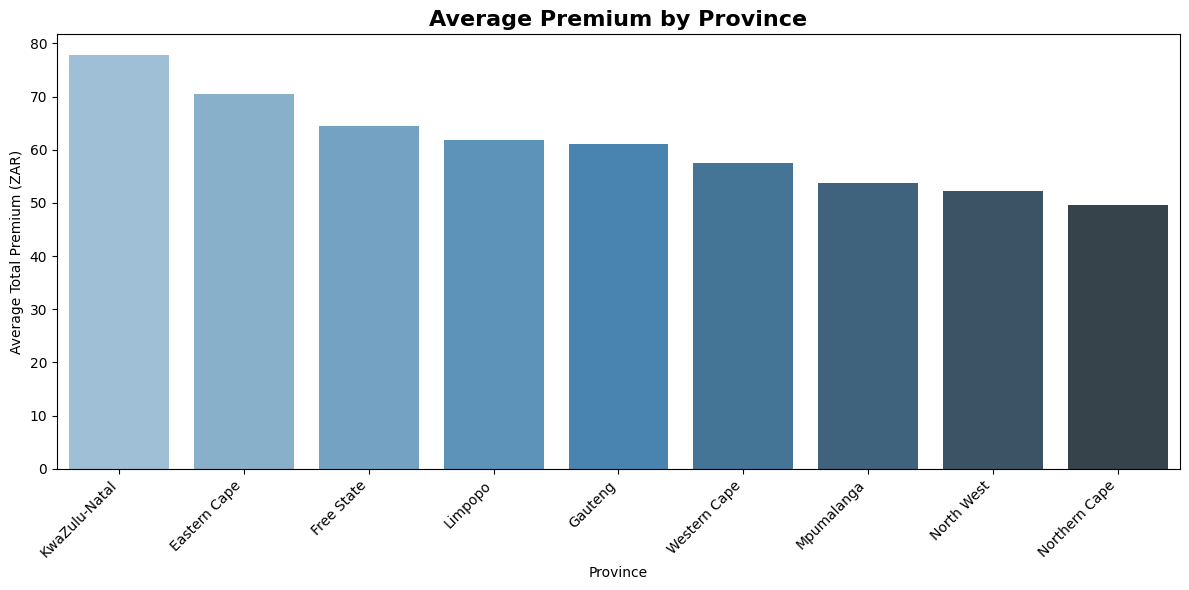

Chart 1 saved!


In [4]:
plt.figure(figsize=(12, 6))

# Average premium per province
province_premium = df.groupby('Province')['TotalPremium'].mean().sort_values(ascending=False)

sns.barplot(x=province_premium.index, y=province_premium.values, palette='Blues_d')

plt.title('Average Premium by Province', fontsize=16, fontweight='bold')
plt.xlabel('Province')
plt.ylabel('Average Total Premium (ZAR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/premium_by_province.png', dpi=150)
plt.show()
print("Chart 1 saved!")

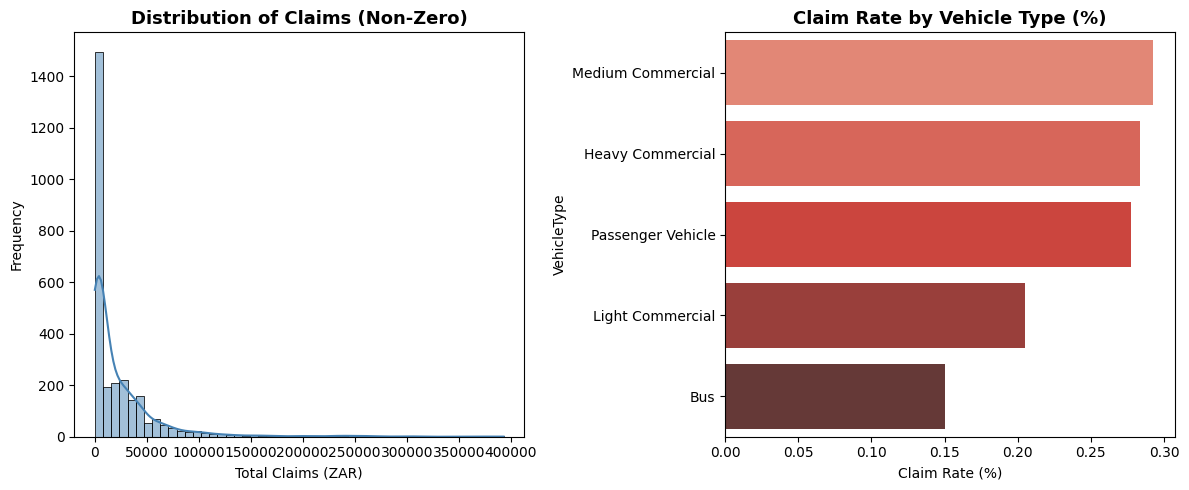

Chart 2 saved!


In [5]:
plt.figure(figsize=(12, 5))

# Filter out zero claims for better visualization
claims_only = df[df['TotalClaims'] > 0]['TotalClaims']

plt.subplot(1, 2, 1)
sns.histplot(claims_only, bins=50, color='steelblue', kde=True)
plt.title('Distribution of Claims (Non-Zero)', fontsize=13, fontweight='bold')
plt.xlabel('Total Claims (ZAR)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
# Claim rate by vehicle type
if 'VehicleType' in df.columns:
    vehicle_claims = df.groupby('VehicleType')['HasClaim'].mean() * 100
    vehicle_claims = vehicle_claims.sort_values(ascending=False).head(10)
    sns.barplot(x=vehicle_claims.values, y=vehicle_claims.index, palette='Reds_d')
    plt.title('Claim Rate by Vehicle Type (%)', fontsize=13, fontweight='bold')
    plt.xlabel('Claim Rate (%)')

plt.tight_layout()
plt.savefig('../reports/claims_distribution.png', dpi=150)
plt.show()
print("Chart 2 saved!")

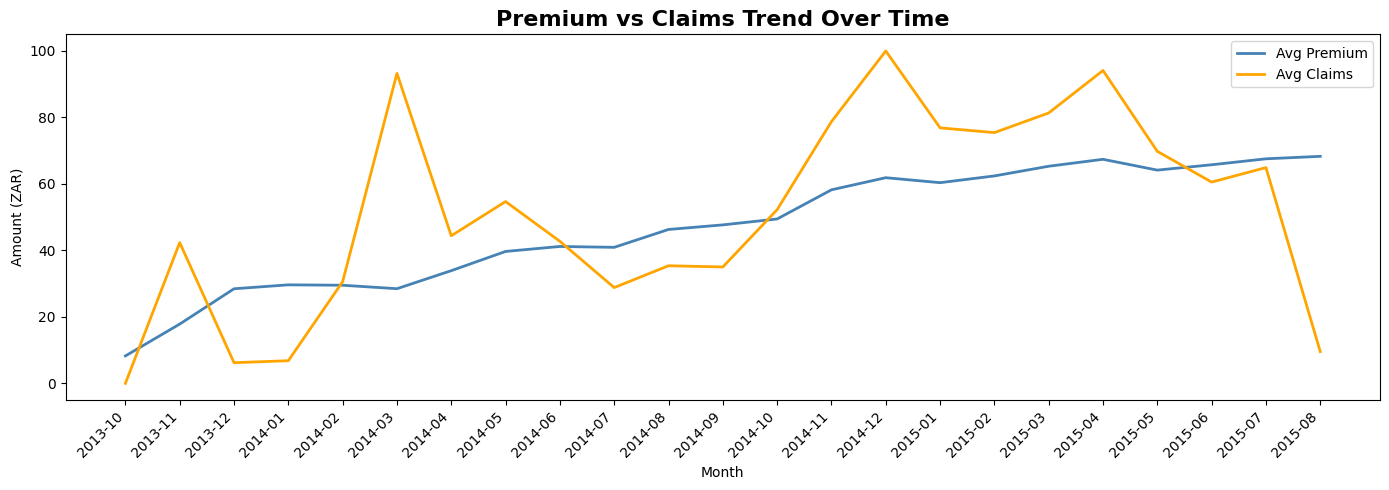

Chart 3 saved!


In [6]:
# Convert transaction date to datetime
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')

# Monthly trends
monthly = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg(
    AvgPremium=('TotalPremium', 'mean'),
    AvgClaims=('TotalClaims', 'mean')
).reset_index()

monthly['TransactionMonth'] = monthly['TransactionMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['TransactionMonth'], monthly['AvgPremium'], 
         label='Avg Premium', color='steelblue', linewidth=2)
plt.plot(monthly['TransactionMonth'], monthly['AvgClaims'], 
         label='Avg Claims', color='orange', linewidth=2)

plt.title('Premium vs Claims Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Amount (ZAR)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/premium_vs_claims_trend.png', dpi=150)
plt.show()
print("Chart 3 saved!")

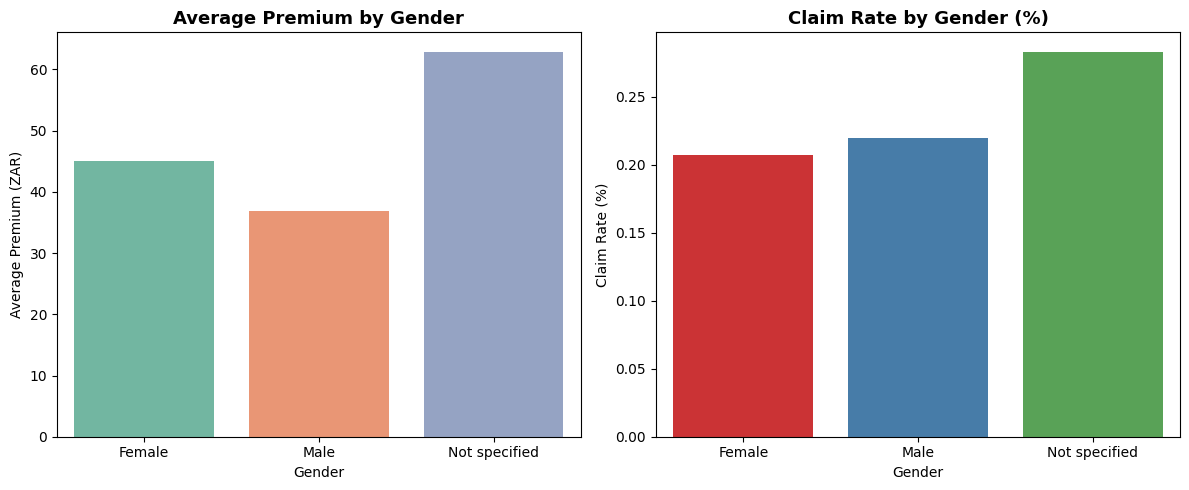

Chart 4 saved!


In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
gender_premium = df.groupby('Gender')['TotalPremium'].mean()
sns.barplot(x=gender_premium.index, y=gender_premium.values, palette='Set2')
plt.title('Average Premium by Gender', fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Premium (ZAR)')

plt.subplot(1, 2, 2)
gender_claims = df.groupby('Gender')['HasClaim'].mean() * 100
sns.barplot(x=gender_claims.index, y=gender_claims.values, palette='Set1')
plt.title('Claim Rate by Gender (%)', fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Claim Rate (%)')

plt.tight_layout()
plt.savefig('../reports/gender_analysis.png', dpi=150)
plt.show()
print("Chart 4 saved!")

In [8]:
print("=" * 60)
print("KEY INSIGHTS — AlphaCare Insurance EDA")
print("=" * 60)

print(f"\nDataset Overview:")
print(f"   Total policies: {len(df):,}")
print(f"   Date range: {df['TransactionMonth'].min()} to {df['TransactionMonth'].max()}")
print(f"   Total provinces: {df['Province'].nunique()}")

print(f"\nPremium Analysis:")
print(f"   Average premium: ZAR {df['TotalPremium'].mean():,.2f}")
print(f"   Max premium: ZAR {df['TotalPremium'].max():,.2f}")
print(f"   Min premium: ZAR {df['TotalPremium'].min():,.2f}")

print(f"\nClaims Analysis:")
print(f"   Policies with claims: {df['HasClaim'].sum():,} ({df['HasClaim'].mean()*100:.1f}%)")
print(f"   Average claim amount: ZAR {df[df['HasClaim']]['TotalClaims'].mean():,.2f}")

print(f"\nTop 3 Provinces by Average Premium:")
top_provinces = df.groupby('Province')['TotalPremium'].mean().sort_values(ascending=False).head(3)
for province, premium in top_provinces.items():
    print(f"   {province}: ZAR {premium:,.2f}")

KEY INSIGHTS — AlphaCare Insurance EDA

Dataset Overview:
   Total policies: 1,000,098
   Date range: 2013-10-01 00:00:00 to 2015-08-01 00:00:00
   Total provinces: 9

Premium Analysis:
   Average premium: ZAR 61.91
   Max premium: ZAR 65,282.60
   Min premium: ZAR -782.58

Claims Analysis:
   Policies with claims: 2,788 (0.3%)
   Average claim amount: ZAR 23,273.39

Top 3 Provinces by Average Premium:
   KwaZulu-Natal: ZAR 77.80
   Eastern Cape: ZAR 70.55
   Free State: ZAR 64.37
